# Code from "Build a Large Language Model From Scratch"
##   - https://www.manning.com/books/build-a-large-language-model-from-scratch
### Code: https://github.com/rasbt/LLMs-from-scratch
#### Copyright (c) Sebastian Raschka under Apache License 2.0 (see LICENSE.txt).
#  
#
#

## Importing useful packages

In [4]:
! pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 9.7 MB/s  0:00:00

[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [23]:
import os
#from google.colab import drive
import urllib.request


os.makedirs('./data', exist_ok=True)
FILE_PATH = "data/AI2.txt"
if not os.path.exists(FILE_PATH):
  url = "https://dl.dropboxusercontent.com/scl/fi/gkpg3zoacp55fti5gbaoj/AI2.txt?rlkey=m41ww22kul14w4fbfo9wmbk9o&dl=0"
  urllib.request.urlretrieve(url, FILE_PATH)
  print("✅ Downloaded", FILE_PATH)
else:
  print(FILE_PATH, "Already exists")

FILE_PATH= "data/the-verdict.txt"
if not os.path.exists(FILE_PATH):
  url = "https://dl.dropboxusercontent.com/scl/fi/tzv0o427pwqwb4m3oap33/the-verdict.txt?rlkey=l17dke8qj8wq9u4scfbuxrbm2&dl=1"
  urllib.request.urlretrieve(url, FILE_PATH)
  print("✅ Downloaded", FILE_PATH)
else:
  print(FILE_PATH, "Already exists")


FILE_PATH= "data/gpt2-small-124M.pth"
if not os.path.exists(FILE_PATH):
  url = "https://www.dropbox.com/scl/fi/4sbwvqptisq67htb98l9v/gpt2-small-124M.pth?rlkey=4nrka9udvuovth67462n125n8&dl=0"
  urllib.request.urlretrieve(url, FILE_PATH)
  print("✅ Downloaded", FILE_PATH)
else:
  print(FILE_PATH, "Already exists")



!ls data

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if True : #(major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
print(device)

data/AI2.txt Already exists
data/the-verdict.txt Already exists
data/gpt2-small-124M.pth Already exists
AI2.txt             gpt2-small-124M.pth the-verdict.txt
mps


In [24]:
from importlib.metadata import version
import os
import requests
pkgs = ["matplotlib",
        "numpy",
        "tiktoken",
        "torch",
        "tensorflow" # For OpenAI's pretrained weights
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import tiktoken

matplotlib version: 3.8.0
numpy version: 1.24.3
tiktoken version: 0.13.0
torch version: 2.2.1
tensorflow version: 2.12.1


# From text to tokens and back
A **tokenizer library**

*   **Splits text into tokens** (words, subwords, or characters)
*   **Maps tokens to numerical IDs**
*   Handles **padding, truncation, and special tokens** (e.g., `[CLS]`, `[SEP]`)
*   Often supports **fast, optimized tokenization** for large datasets


In [25]:


def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())



In [26]:


prompt = "I like studying machine learning but this is difficult since I need to know a lot of notions and I have to revise my classes of statistics"

tokenizer = tiktoken.get_encoding("gpt2")
encoded = text_to_token_ids(prompt,tokenizer)
print("Encoded text=", encoded)
decoded_text = token_ids_to_text(encoded,tokenizer)
print("Encoded text=", decoded_text)


Encoded text= tensor([[   40,   588, 11065,  4572,  4673,   475,   428,   318,  2408,  1201,
           314,   761,   284,   760,   257,  1256,   286, 26226,   290,   314,
           423,   284, 32548,   616,  6097,   286,  7869]])
Encoded text= I like studying machine learning but this is difficult since I need to know a lot of notions and I have to revise my classes of statistics


# Creating a dataset from text

In PyTorch, a **DataLoader** is a utility that **efficiently feeds data to your model during training or evaluation**. It wraps a dataset and handles:

*   **Batching** data (grouping samples into mini‑batches)
*   **Shuffling** data each epoch (for better training)
*   **Loading data in parallel** using multiple worker processes
*   **Automatically iterating** over the dataset



In [27]:


#####################################
# Data Loader
#####################################


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride, verbose= False):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        if max_length>len(token_ids):
            max_length=len(token_ids)-1
        cnt=0
        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            if verbose:
              print(cnt, "th input=", tokenizer.decode(input_chunk))
              print(cnt, "th output=",tokenizer.decode(target_chunk), "\n")
              cnt+=1
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0, verbose=False):
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride, verbose)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader


In [28]:
D=create_dataloader_v1(prompt, max_length=10, stride=2, verbose=True)

0 th input= I like studying machine learning but this is difficult since
0 th output=  like studying machine learning but this is difficult since I 

1 th input=  studying machine learning but this is difficult since I need
1 th output=  machine learning but this is difficult since I need to 

2 th input=  learning but this is difficult since I need to know
2 th output=  but this is difficult since I need to know a 

3 th input=  this is difficult since I need to know a lot
3 th output=  is difficult since I need to know a lot of 

4 th input=  difficult since I need to know a lot of notions
4 th output=  since I need to know a lot of notions and 

5 th input=  I need to know a lot of notions and I
5 th output=  need to know a lot of notions and I have 

6 th input=  to know a lot of notions and I have to
6 th output=  know a lot of notions and I have to revise 

7 th input=  a lot of notions and I have to revise my
7 th output=  lot of notions and I have to revise my classes 

8 th in

# Creating a transformer

In [29]:




#####################################
# MultiHeadAttention
#####################################
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "MultiHeadAttention d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec


#####################################
# Normalisation Layer
#####################################
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False) # decoding to V size

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape ## [batch_size, num_tokens]
        tok_embeds = self.tok_emb(in_idx)  ## Embedding ## [batch_size, num_tokens, emb_dim]
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))  ## Positional embedding ## [batch_size, num_tokens, emb_dim]
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_dim]
        x = self.drop_emb(x) # Shape [batch_size, num_tokens, emb_dim]
        x = self.trf_blocks(x) # Shape [batch_size, num_tokens, emb_dim]
        x = self.final_norm(x) # Shape [batch_size, num_tokens, emb_dim]
        logits = self.out_head(x) # Shape [batch_size, num_tokens, vocab_size]
        return logits






## GPT definition

In [30]:


GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 512,  # Context length n
    "emb_dim": 768,          # Embedding dimension d
    "n_heads": 12,           # Number of attention heads : dim_heads=embd_dim/n_heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}



## Text generators from GPT

In [31]:
def generate_text_simple(model, idx, max_new_tokens, context_size, verbose= False):
    # idx is (B, n) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
          if verbose:
              print("input shape= ", idx_cond.shape) # [B,n]
              print("input shape= ", token_ids_to_text(idx_cond,tokenizer))
          logits = model(idx_cond)
          if verbose:
            print("output shape=", logits.shape) # [B,n,V ]

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

## Generating text from untrained GPT

In [32]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

model.eval()  # disable dropout

prompt = "This class talks about Deep learning. Deep learning is"

encoded_tensor = text_to_token_ids(prompt,tokenizer)

print(f"\n{50*'='}\n{22*' '}IN\n{50*'='}")
print("\nInput text:", prompt)
print("Encoded input text:", encoded_tensor)
print("encoded_tensor.shape:", encoded_tensor.shape)

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
decoded_text = token_ids_to_text(out,tokenizer)

print(f"\n\n{50*'='}\n{22*' '}OUT\n{50*'='}")
print("\nOutput:", out)
print("Output length:", len(out[0]))
print("Output text:", decoded_text)

Total number of parameters: 162,616,320

                      IN

Input text: This class talks about Deep learning. Deep learning is
Encoded input text: tensor([[ 1212,  1398,  6130,   546, 10766,  4673,    13, 10766,  4673,   318]])
encoded_tensor.shape: torch.Size([1, 10])


                      OUT

Output: tensor([[ 1212,  1398,  6130,   546, 10766,  4673,    13, 10766,  4673,   318,
         36727,  8686,  8731, 39857, 14828, 45278, 37447, 22147, 42241, 47633]])
Output length: 20
Output text: This class talks about Deep learning. Deep learning isPolicy assignedWind carnage Cob 1861Already unsure effortlessly semifinals


## Loading training text

In [33]:


file_path = "data/the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"
file_path = "data/AI2.txt"
url = "https://raw.githubusercontent.com/gbonte/gbcodepy/main/AI.txt"
if not os.path.exists(file_path):
    print("Downloading the file from the web")
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
        print("Written the file", file_path, " locally")
else:
    print("Reading the local file", file_path)
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)
print(text_data[:100])


Reading the local file data/AI2.txt
Characters: 30716
Tokens: 5408


Artificial Intelligence: Understanding a Transformative Technology

Artificial Intelligence, commo


## Preparing training and test datasets from text

In [34]:

# Train/validation ratio
train_ratio = 0.8
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)
print(len(train_data), len(val_data))
print(len(train_loader.dataset), len(val_loader.dataset))

24572 6144
8 1


In [35]:
# Sanity check

#print(val_data)

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 512]) torch.Size([2, 512])
torch.Size([2, 512]) torch.Size([2, 512])
torch.Size([2, 512]) torch.Size([2, 512])
torch.Size([2, 512]) torch.Size([2, 512])

Validation loader:
torch.Size([1, 512]) torch.Size([1, 512])


## Training functions

In [36]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()


In [38]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if True: #(major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss before any training :", train_loss)
print("Validation loss before any training :", val_loss)

Using mps device.
Training loss before any training : 10.981072902679443
Validation loss before any training : 10.972118377685547


## LLM training

In [39]:
# Note:
# Uncomment the following code to calculate the execution time
# import time
# start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

#prompt="Every effort moves you"
prompt="The mission of data science is"
num_epochs = 50
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=prompt, tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
# end_time = time.time()
# execution_time_minutes = (end_time - start_time) / 60
# print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.289, Val loss 9.679
The mission of data science is                                                  
Ep 2 (Step 000005): Train loss 7.411, Val loss 8.177
The mission of data science is, and.                                               
Ep 3 (Step 000010): Train loss 6.074, Val loss 7.342
The mission of data science is, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and
Ep 4 (Step 000015): Train loss 10.298, Val loss 11.909
The mission of data science is recipe.                                                
The mission of data science is a to AI, and                                             
Ep 6 (Step 000020): Train loss 4.831, Val loss 7.193
The mission of data science is                                                  
Ep 7 (Step 000025): Train loss 4.057, Val loss 7.284
The mission of data science is not a machine learning, and data science is not and data science is a o

KeyboardInterrupt: 

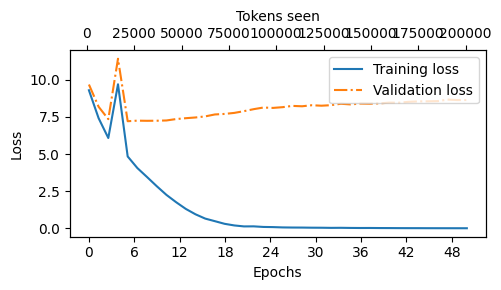

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator



epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Test of the learned model

In [18]:
# NEW: use CPU here as inference is cheap with
# this model and to ensure readers get same results in the
# remaining sections of this book
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

promt="The mission of data science is "
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(promt, tokenizer).to(inference_device),
    max_new_tokens=20,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output  simple text:\n", token_ids_to_text(token_ids, tokenizer))

token_ids = generate(
    model=model,
    idx=text_to_token_ids(promt, tokenizer).to(inference_device),
    max_new_tokens=20,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=50,
    temperature=0.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output  simple text:
 The mission of data science is  to capture complex relationships. Convolutional neural networks handle spatial data such as images, while sequence models
Output text:
 The mission of data science is  to capture complex relationships. Convolutional neural networks handle spatial data such as images, while sequence models


# Using existing GPT2 models

Note that you cannot import GPT‑3 as a PyTorch model or class.
GPT‑3 is not released as weights or source code. You can only use it via the OpenAI API.

In [19]:
import os
import urllib.request

file_name = "gpt2-small-124M.pth"
#file_name = "gpt2-medium-355M.pth"
#file_name = "gpt2-large-774M.pth"
#file_name = "gpt2-xl-1558M.pth"

url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"

if not os.path.exists(file_name):
    print("Retrieving from the web ", file_name)
    urllib.request.urlretrieve(url, file_name)
    print(f"Downloaded to {file_name}")
else:
    print(f"File {file_name} already exists locally")


Retrieving from the web  gpt2-small-124M.pth
Downloaded to gpt2-small-124M.pth


## Test different gpt2 sizes

In [21]:
format="small"


if format=="small":
  file_name="gpt2-small-124M.pth"
  BASE_CONFIG = {
      "vocab_size": 50257,    # Vocabulary size
      "context_length": 1024, # Context length
      "drop_rate": 0.0,       # Dropout rate
      "qkv_bias": True,        # Query-key-value bias
      "emb_dim": 768 ,       # Embedding dimension
      "n_heads": 12,          # Number of attention heads
      "n_layers": 12          # Number of layers
  }
if format=="medium":
  file_name="gpt2-medium-355M.pth"
  BASE_CONFIG = {
      "vocab_size": 50257,     # GPT‑2 BPE vocabulary
      "context_length": 1024,  # Maximum sequence length
      "drop_rate": 0.0,        # GPT‑2 uses no dropout at inference
      "qkv_bias": True,        # GPT‑2 uses bias in QKV projections
      "emb_dim": 1024,         # Embedding / hidden size
      "n_heads": 16,           # Attention heads (1024 / 16 = 64 per head)
      "n_layers": 24           # ✅ GPT‑2 Medium has 24 layers
  }

if format=="large":
  file_name="gpt2-large-774M.pth"
  BASE_CONFIG = {
    "vocab_size": 50257,     # GPT‑2 BPE vocabulary
    "context_length": 1024,  # Maximum sequence length
    "drop_rate": 0.0,        # No dropout at inference
    "qkv_bias": True,        # Bias in QKV projections
    "emb_dim": 1280,         # ✅ Larger embedding dimension
    "n_heads": 20,           # ✅ Attention heads (1280 / 20 = 64 per head)
    "n_layers": 36           # ✅ Number of transformer blocks
  }


gpt = GPTModel(BASE_CONFIG)
gpt.load_state_dict(torch.load(file_name, weights_only=False))
gpt.eval()


gpt.to(device);


torch.manual_seed(123)
prompt="The mission of data science is"
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids(prompt, tokenizer).to(device),
    max_new_tokens=25,
    context_size=BASE_CONFIG["context_length"],
    top_k=50,
    temperature=10.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 The mission of data science is as important the evolution can benefit because humans (and those with data of such data about itself)" "That includes being prepared physically
